In [2]:
import langgraph 
from dotenv import load_dotenv
load_dotenv()
import os
from config.config import settings

In [3]:
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langgraph"

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
llm

/home/lucifer/GenAI/BUDDY/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x78e3952c1ac0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x78e394f0b2c0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

#### Start building chatbot using langgraph

In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)
graph_builder

In [7]:
def chatbot(state: State):
    return {"messages": llm.invoke(state['messages'])}

In [8]:
graph_builder.add_node(node="chatbot", action=chatbot)

In [9]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [10]:
graph = graph_builder.compile()

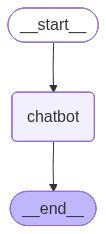

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "\q"]:
        print("good bye")
        break
    for event in graph.stream({'messages': ("user", user_input)}):
        print(event.values())
        for value in event.values():
            print
            print(f"Assistant: {value["messages"].content}")
    

<>:3: SyntaxWarning: invalid escape sequence '\q'
<>:3: SyntaxWarning: invalid escape sequence '\q'
/tmp/ipykernel_61790/1182053530.py:3: SyntaxWarning: invalid escape sequence '\q'
  if user_input.lower() in ["quit", "\q"]:


dict_values([{'messages': AIMessage(content='<think>\nOkay, the user said "hello". I need to respond appropriately. Let me check the guidelines. The response should be friendly and open-ended. Maybe ask how I can assist them. Keep it simple and welcoming. Alright, something like "Hello! How can I assist you today?" That should work.\n</think>\n\nHello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 9, 'total_tokens': 84, 'completion_time': 0.135002443, 'completion_tokens_details': None, 'prompt_time': 0.00046616, 'prompt_tokens_details': None, 'queue_time': 0.314094409, 'total_time': 0.135468603}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_99d722e776', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb879-7850-7101-890d-4304f03c1b9e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 

counter: 6
doubling
counter: 13
doubling
{'counter': 26, 'user_query': 'Please do it again'}


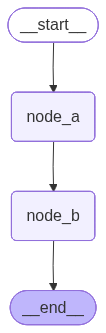

In [40]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import random

# 1. Define State
class State(TypedDict):
    counter: int
    user_query: str

# 2. Define Nodes
def node_a(state: State):
    counter = state.get("counter")
    print(f"counter: {counter + 1}")
    return {"counter": state["counter"] + 1}

def node_b(state: State):
    print("doubling")
    return {"counter": state["counter"] * 2}

def node_decide_next_node(state: State):
    user_text = state.get("user_query", "").lower()
    counter = state.get("counter")
    if "again" in user_text and counter < 20:
        return "node_a"
    return END

# 3. Build Graph
workflow = StateGraph(State)
workflow.add_node("node_a", node_a)
workflow.add_node("node_b", node_b)

workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_conditional_edges(source="node_b",
                               path=node_decide_next_node)

# 4. Compile and Run
app = workflow.compile()
print(app.invoke({"counter": 5, "user_query": "Please do it again"}))

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [31]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
import random

class State(TypedDict):
    counter: int

def node_a(state: State):
    print(f"--- Node A: Counter is {state['counter']} ---")
    return {"counter": state["counter"] + 1}

def node_b(state: State):
    print(f"--- Node B: Doubling! ---")
    return {"counter": state["counter"] * 2}

# 1. The Router Function
def decide_next_node(state: State) -> Literal["node_a", END]:
    if state["counter"] > 20:
        return END
    return random.choice(["node_a", END])

workflow = StateGraph(State)
workflow.add_node("node_a", node_a)
workflow.add_node("node_b", node_b)

workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")

# 2. Add the Conditional Edge
# "If we are at node_b, call decide_next_node to see where to go next"
workflow.add_conditional_edges(
    "node_b", 
    decide_next_node
)

app = workflow.compile()
# Run it with a low number and watch it loop (or stop) randomly!
print(app.invoke({"counter": 5}))

--- Node A: Counter is 5 ---
--- Node B: Doubling! ---
--- Node A: Counter is 12 ---
--- Node B: Doubling! ---
{'counter': 26}


================================ Human Message =================================

What's the weather like in Washington DC?
================================== Ai Message ==================================
Tool Calls:
  get_current_weather (vp1199vyp)
 Call ID: vp1199vyp
  Args:
    location: Washington DC
================================= Tool Message =================================
Name: get_current_weather

The weather at Washington DC is sunny. :)
================================== Ai Message ==================================

The weather in Washington DC is currently sunny. 😊


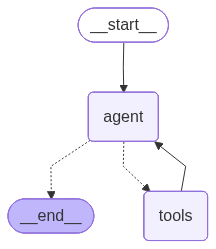

In [57]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_groq import ChatGroq

@tool
def get_user_weight_goal(username: str):
    """Look up the weight goal for a specific user."""
    # In reality, this would query your MongoDB
    if username.lower() == "ashrit":
        return "Goal is 85-90 kg."
    return "User not found."

@tool
def get_current_weather(location: str):
    """
    Returns the weather of the location
    """
    return f"The weather at {location} is sunny. :)"

# 2. Initialize the Brain
# Replace with your actual API key or use env variables
llm = ChatGroq(model="qwen/qwen3-32b") 

tools = [get_user_weight_goal, get_current_weather]

# 3. Bind the Tool
llm_with_tools = llm.bind_tools(tools)

# Define agent node
def call_model(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# build graph
builder = StateGraph(MessagesState)
builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")

graph = builder.compile()

inputs = {"messages": [("user", "What's the weather like in Washington DC?")]}
for chunk in graph.stream(inputs, stream_mode="values"):
    chunk["messages"][-1].pretty_print()
    
    
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass